In [105]:
import numpy as np
import matplotlib.pyplot as plt
import opt_einsum as oe

from quant_rotor.core.dense.hamiltonian import hamiltonian_dense
from quant_rotor.core.dense.hamiltonian_big import hamiltonian_general_dense

from quant_rotor.core.dense.de_solve_one_thermal import integration_scheme
from quant_rotor.core.dense.de_solve_one_thermal_dense import integration_scheme as integration_scheme_fast
import quant_rotor.models.dense.thermofield_boltz_funcs as bz
from quant_rotor.models.dense.TF_state_optimizer import TF_optimizer

from quant_rotor.models.dense.stat_mech_thermo import Z
from quant_rotor.models.dense.stat_mech_thermo import U as U_stat

In [106]:
site = 3
state = 3
g = 0.1

D = 1

In [107]:
state_2 = state**2

# Construct a guess

In [108]:
V_pq = np.zeros((state, state))
for p in range(state):
    for q in range(state):
        if p == q:
            V_pq[p, q] = 1
V_pq = (V_pq / np.linalg.norm(V_pq)).reshape(state**2)

In [109]:
H, K, V = hamiltonian_dense(state, site, g, D=D)

In [110]:
U_opt = TF_optimizer(site, state, K, V)

Constduncted TF hamiltonian.
Constduncted degenerate ground basis.
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.014061809613819753
       x: [ 2.036e-01  3.542e-02 ...  2.180e-01  2.737e-01]
     nit: 17
     jac: [-8.029e-01 -1.397e-01 ... -8.597e-01 -1.079e+00]
    nfev: 493
    njev: 17
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: (0.014061809844620021+0j)
       x: [ 1.000e-05]
     nit: 1
     jac: [ 4.286e-05]
    nfev: 2
    njev: 1


In [111]:
C_lambda = np.linalg.solve(U_opt, V_pq)
t_0 = np.log(C_lambda[0])
t_ai = C_lambda[1:] / C_lambda[0]

In [112]:
C_lambda

array([-0.66627282-0.j,  0.19415056+0.j,  0.19850763+0.j, -0.01960568-0.j,
        0.01185702+0.j,  0.05339335+0.j,  0.07312985+0.j,  0.65550113+0.j,
        0.20143305+0.j])

In [113]:
t_0

np.complex128(-0.40605604647810073-3.141592653589793j)

In [114]:
t_ai

array([-0.29139798-0.j, -0.29793746-0.j,  0.0294259 -0.j, -0.01779605-0.j,
       -0.08013737-0.j, -0.10975961-0.j, -0.98383291-0.j, -0.30232818-0.j])

In [115]:
V_pq

array([0.57735027, 0.        , 0.        , 0.        , 0.57735027,
       0.        , 0.        , 0.        , 0.57735027])

In [116]:
U_opt @ C_lambda

array([ 5.77350269e-01+0.j, -5.55111512e-17+0.j, -5.55111512e-17+0.j,
        7.80625564e-18+0.j,  5.77350269e-01+0.j, -1.57615891e-17+0.j,
       -2.77555756e-17+0.j, -6.18884623e-17+0.j,  5.77350269e-01+0.j])

In [117]:
U, _ = bz.thermofield_change_of_basis(K)

In [118]:
C_lambda_oz = np.linalg.solve(U, V_pq)
t_0_oz = np.log(C_lambda_oz[0])
t_ai_oz = C_lambda_oz[1:]
C_lambda_oz

array([ 1., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.])

# Construct kinetic and potential in TF.

In [119]:
U, _ = bz.thermofield_change_of_basis(K)
I = np.eye(state)

K_prim = oe.contract('pq,mw->pmqw', K, I,  optimize='optimal')
K_tilda_kron = U.T @ K_prim.reshape(state_2, state_2) @ U

V_prim = oe.contract('pqrs,mw,nv->pmqnrwsv', V.reshape(state, state, state, state), I, I,  optimize='optimal')

U_kron = np.kron(U, U)

V_tilda_kron = U_kron.T @ V_prim.reshape(state_2**2, state_2**2) @ U_kron

In [120]:
grouped = False

In [121]:
U_opt_kron = np.kron(U_opt, U_opt)

In [122]:
if grouped:
    K_opt_grd = U_opt.T.conj()@  K_prim.reshape(state_2, state_2) @ U_opt
    V_opt_grd = U_opt.conj().T @ V_prim.reshape(state_2**2, state_2**2) @ U_opt
else:
    K_opt_grd = U_opt.T.conj()@  K_tilda_kron @ U_opt
    V_opt_grd = U_opt_kron.conj().T @ V_tilda_kron @ U_opt_kron

# Annalise

In [123]:
# time_TF_guess, energy_TF_guess, t_1_max_TF_guess, _  = integration_scheme(site, state_2, g, t_init=0,t_final=20,nof_points=100000, Import=True, K_import=K_tilda_kron, V_import=V_tilda_kron.reshape(state_2, state_2, state_2, state_2), import_guess=True, t_0_import=t_0_oz, single_import=t_ai_oz)

In [124]:
time_TF, energy_TF, t_1_max_TF, _  = integration_scheme(site, state_2, 1, t_init=0,t_final=20,nof_points=100000, Import=True, K_import=K_tilda_kron, V_import=V_tilda_kron.reshape(state_2, state_2, state_2, state_2))

In [125]:
time_TF_guess_opt, energy_TF_guess_opt, t_1_max_TF_guess_opt, _ = integration_scheme(site, state_2, 1, t_init=0,t_final=20,nof_points=100000, Import=True, K_import=K_opt_grd, V_import=V_opt_grd.reshape(state_2, state_2, state_2, state_2), import_guess=True, t_0_import=t_0, single_import=t_ai)

In [126]:
# time_prim, energy_prim, t_1_max_prim, _ = integration_scheme(site, state_2, 1, t_init=0,t_final=20,nof_points=100000, Import=True, K_import=K_prim.reshape(state_2, state_2), V_import=V_prim.reshape(state_2, state_2, state_2, state_2))

In [127]:
eig_val_ED, eig_vec_ED = np.linalg.eigh(H)

In [128]:
ED_U_val = np.array([U_stat(eig_val_ED, x) for x in time_TF])

In [129]:
# plt.plot(time_TF[time_TF <= 15], (ED_U_val/site)[time_TF <= 15], label=f"Exact U g = {g}")
# plt.plot(time_prim[time_TF <= 15],( -energy_prim/site)[time_TF <= 15], label=f"Prim g = {g}")
# plt.plot(time_TF[time_TF <= 15], (-energy_TF/site)[time_TF <= 15], label=f"Oz g = {g}", linestyle=':')
# plt.plot(time_TF_guess[time_TF_guess <= 15], (-energy_TF_guess/site)[time_TF_guess <= 15], label=f"Opt g = {g}", linestyle=':', color = "black")
# plt.title("Energy Imaginary Time Propagation (Os Basis)")
# plt.xlabel("Time")
# plt.ylabel("Energy")
# plt.legend()
# plt.show()

In [130]:
ED_U_val[0]

np.float64(2.0)

In [131]:
energy_TF[0]

np.complex128(-2+0j)

In [132]:
energy_TF_guess_opt[0]

np.complex128(0.03878884496296782-0j)

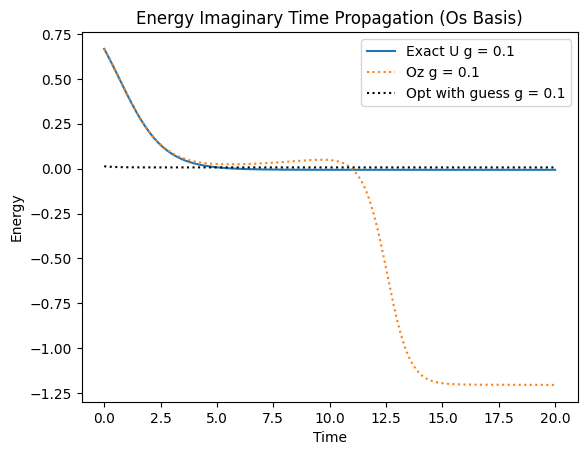

In [133]:
plt.plot(time_TF, (ED_U_val/site), label=f"Exact U g = {g}")
# plt.plot(time_prim,( -energy_prim/site), label=f"Prim g = {g}")
plt.plot(time_TF, (-energy_TF/site), label=f"Oz g = {g}", linestyle=':')
# plt.plot(time_TF_guess, (-energy_TF_guess/site), label=f"Oz with guess g = {g}", linestyle=':', color = "red")
plt.plot(time_TF_guess_opt, (energy_TF_guess_opt/site), label=f"Opt with guess g = {g}", linestyle=':', color = "black")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

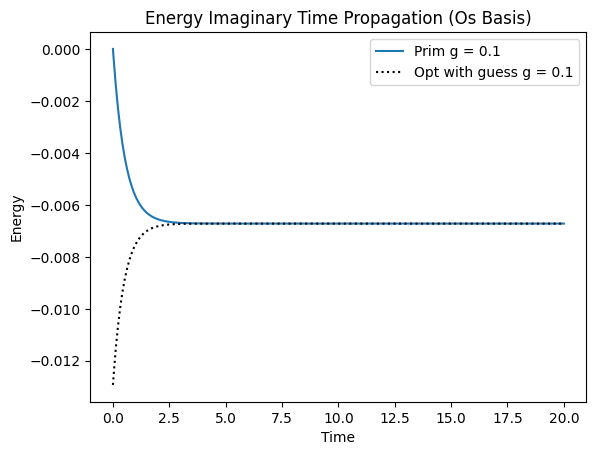

In [134]:
plt.plot(time_prim, -energy_prim/site, label=f"Prim g = {g}")
plt.plot(time_TF_guess_opt, (-energy_TF_guess_opt/site), label=f"Opt with guess g = {g}", linestyle=':', color = "black")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

In [135]:
ED_U_val[-1]

np.float64(-0.02002093670411428)

In [136]:
energy_TF_guess[-1]

np.complex128(3.6137255489299953-0j)